# IEEE-CIS Fraud Detection — Exploratory Data Analysis

Before building any model, we need to understand what we're working with.

This notebook answers the questions that drive every design decision in the pipeline:
- How severe is the class imbalance?
- What does fraud look like in time — is there a pattern by hour or day?
- How does transaction amount differ between fraud and legitimate?
- Which columns have too many nulls to be useful?
- Do the card and address features carry signal?
- What does the identity table add?

## 0. Setup

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Clean plot style
plt.rcParams.update({
    'figure.figsize':  (10, 4),
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.3,
    'font.size':          11,
})

FRAUD_COLOR  = '#DC2626'   # red
LEGIT_COLOR  = '#2563EB'   # blue
DATA_PATH    = r'C:\Users\user\Downloads\files\fraud_detection\data\raw'

## 1. Load the data

In [13]:
txn = pd.read_csv(f'{DATA_PATH}\\train_transaction.csv')
idn = pd.read_csv(f'{DATA_PATH}\\train_identity.csv')

print(f'Transactions : {txn.shape[0]:,} rows  x  {txn.shape[1]} columns')
print(f'Identity     : {idn.shape[0]:,} rows  x  {idn.shape[1]} columns')

Transactions : 590,540 rows  x  394 columns
Identity     : 144,233 rows  x  41 columns


In [14]:
txn.head(3)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
idn.head(3)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows


## 2. Class imbalance

The first question in any fraud project: how rare is fraud?

This determines everything — which metric to use, how to handle the training loss, and why accuracy is meaningless here.

In [16]:
fraud_rate = txn['isFraud'].mean()
counts     = txn['isFraud'].value_counts()

print(f'Total transactions : {len(txn):,}')
print(f'Fraudulent         : {counts[1]:,}  ({fraud_rate:.2%})')
print(f'Legitimate         : {counts[0]:,}  ({1 - fraud_rate:.2%})')
print()
print(f'A model that predicts NEVER FRAUD achieves {1 - fraud_rate:.2%} accuracy.')
print('This is why accuracy is the wrong metric for fraud detection.')

Total transactions : 590,540
Fraudulent         : 20,663  (3.50%)
Legitimate         : 569,877  (96.50%)

A model that predicts NEVER FRAUD achieves 96.50% accuracy.
This is why accuracy is the wrong metric for fraud detection.


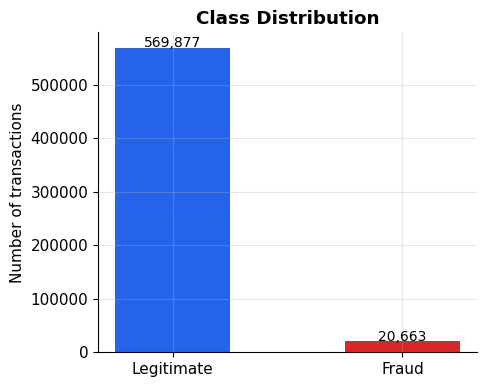

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ['Legitimate', 'Fraud'],
    [counts[0], counts[1]],
    color=[LEGIT_COLOR, FRAUD_COLOR],
    width=0.5,
)
ax.set_ylabel('Number of transactions')
ax.set_title('Class Distribution', fontweight='bold')
for bar, val in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Time patterns

`TransactionDT` is seconds elapsed from some reference point — not a real timestamp.
We can still extract hour-of-day and day-of-week, which are strong fraud signals.

Fraud operations centres are less staffed at night and on weekends.
Victims are asleep. Both effects push fraud toward these windows.

C:\Users\user\AppData\Local\Temp\ipykernel_20384\853598657.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  txn['hour']       = (txn['TransactionDT'] % 86400  // 3600).astype(int)
C:\Users\user\AppData\Local\Temp\ipykernel_20384\853598657.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  txn['day_of_week'] = (txn['TransactionDT'] % 604800 // 86400).astype(int)


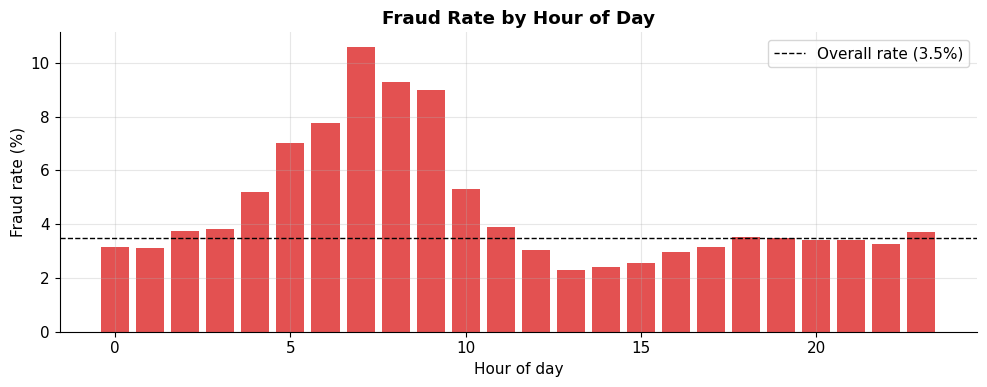

In [18]:
txn['hour']       = (txn['TransactionDT'] % 86400  // 3600).astype(int)
txn['day_of_week'] = (txn['TransactionDT'] % 604800 // 86400).astype(int)

# Fraud rate by hour of day
hourly = txn.groupby('hour')['isFraud'].mean().reset_index()

fig, ax = plt.subplots()
ax.bar(hourly['hour'], hourly['isFraud'] * 100, color=FRAUD_COLOR, alpha=0.8)
ax.axhline(fraud_rate * 100, color='black', linestyle='--',
           linewidth=1, label=f'Overall rate ({fraud_rate:.1%})')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Hour of Day', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

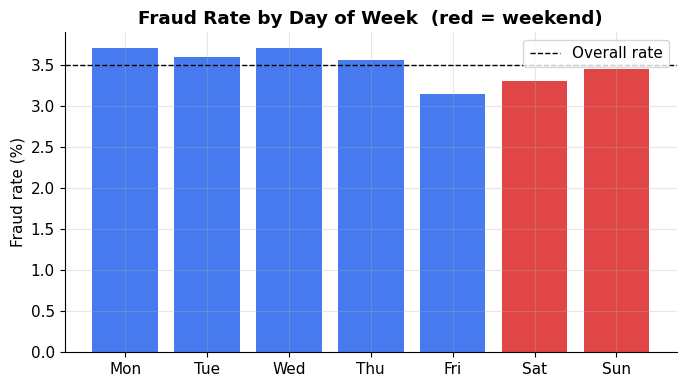

In [19]:
# Fraud rate by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = txn.groupby('day_of_week')['isFraud'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 4))
colors = [FRAUD_COLOR if d in [5, 6] else LEGIT_COLOR
          for d in daily['day_of_week']]
ax.bar(daily['day_of_week'], daily['isFraud'] * 100, color=colors, alpha=0.85)
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.axhline(fraud_rate * 100, color='black', linestyle='--', linewidth=1,
           label='Overall rate')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Day of Week  (red = weekend)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Transaction amount

Do fraudulent transactions look different in size?
This shapes the `amt_zscore_from_card` feature — we need to know if amount is discriminative at all.

In [20]:
fraud = txn[txn['isFraud'] == 1]['TransactionAmt']
legit = txn[txn['isFraud'] == 0]['TransactionAmt']

print('Transaction Amount Summary')
print(f'{"":20} {"Legitimate":>12} {"Fraud":>12}')
print('-' * 46)
for stat in ['mean', '50%', '75%', '95%', 'max']:
    l = legit.describe()[stat] if stat != '95%' else legit.quantile(0.95)
    f = fraud.describe()[stat] if stat != '95%' else fraud.quantile(0.95)
    label = 'median' if stat == '50%' else stat
    print(f'{label:20} {l:>12.2f} {f:>12.2f}')

Transaction Amount Summary
                       Legitimate        Fraud
----------------------------------------------
mean                       134.51       149.24
median                      68.50        75.00
75%                        120.00       161.00
95%                        435.00       500.00
max                      31937.39      5191.00


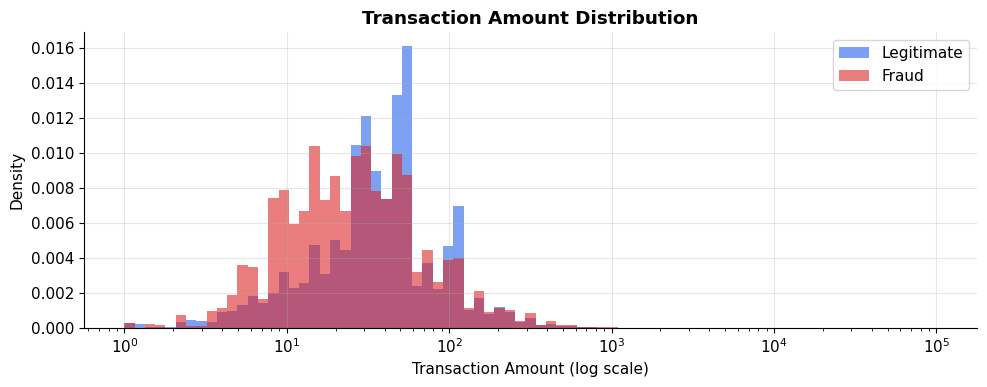

In [21]:
fig, ax = plt.subplots()
bins = np.logspace(0, 5, 80)
ax.hist(legit, bins=bins, alpha=0.6, color=LEGIT_COLOR,
        label='Legitimate', density=True)
ax.hist(fraud, bins=bins, alpha=0.6, color=FRAUD_COLOR,
        label='Fraud', density=True)
ax.set_xscale('log')
ax.set_xlabel('Transaction Amount (log scale)')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount Distribution', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Missing values

Which columns have too much missingness to be useful?
This directly informs the V-feature filtering threshold in the pipeline.

In [22]:
missing = txn.isnull().mean().sort_values(ascending=False)

# Summary by threshold
for threshold in [0.9, 0.7, 0.5, 0.3, 0.1]:
    n = (missing > threshold).sum()
    print(f'Columns with >{threshold:.0%} missing: {n}')

Columns with >90% missing: 2
Columns with >70% missing: 168
Columns with >50% missing: 174
Columns with >30% missing: 192
Columns with >10% missing: 282


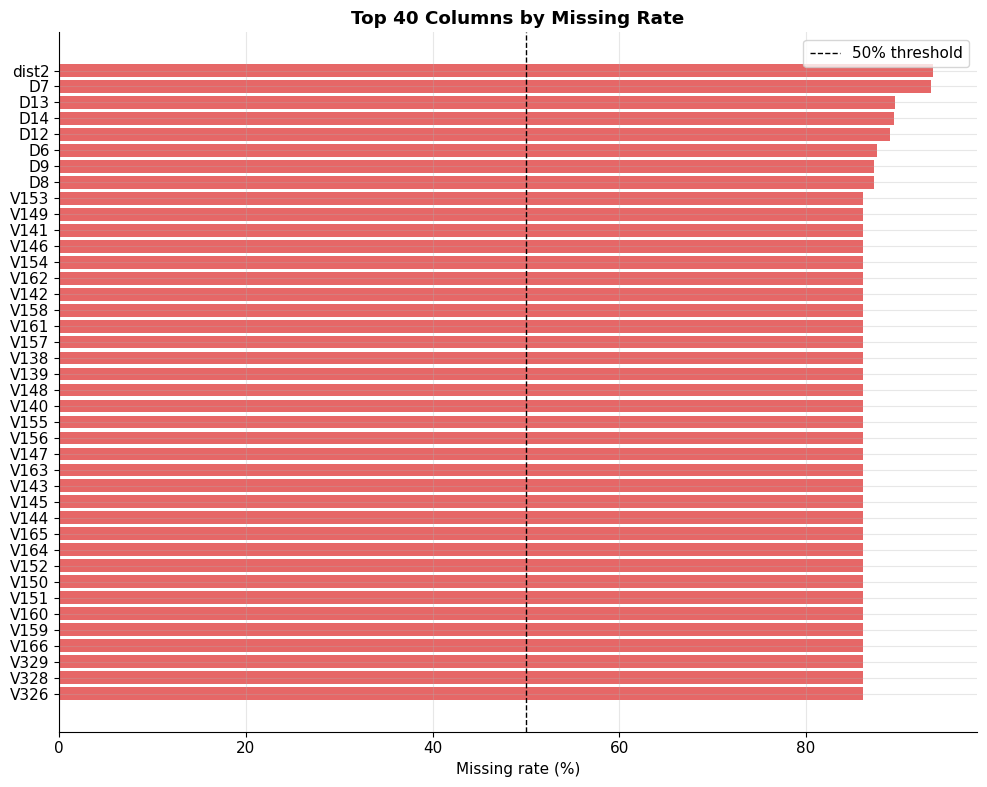

In [23]:
# Plot top 40 most missing columns
top_missing = missing[missing > 0].head(40)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_missing.index[::-1], top_missing.values[::-1] * 100,
        color=FRAUD_COLOR, alpha=0.7)
ax.axvline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel('Missing rate (%)')
ax.set_title('Top 40 Columns by Missing Rate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6. V-features

There are 339 anonymised V-features from Vesta. We need to understand their missingness and variance before deciding how to handle them.

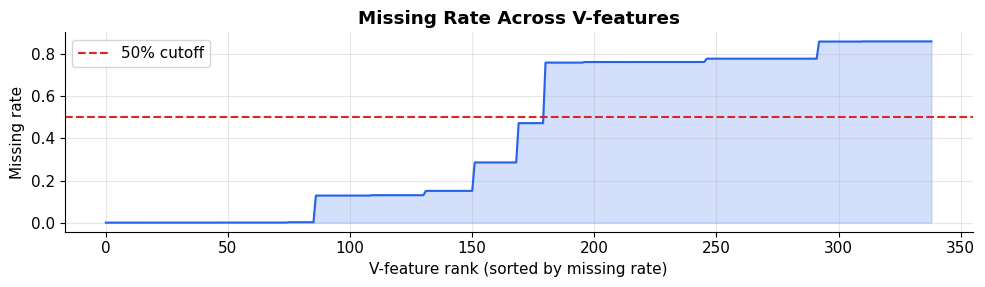

V-features to keep (<=50% missing): 180
V-features to drop  (>50% missing): 159


In [24]:
v_cols = [c for c in txn.columns if c.startswith('V')]
v_missing = txn[v_cols].isnull().mean()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(range(len(v_cols)), sorted(v_missing.values), color=LEGIT_COLOR)
ax.axhline(0.5, color=FRAUD_COLOR, linestyle='--', label='50% cutoff')
ax.fill_between(range(len(v_cols)), sorted(v_missing.values),
                alpha=0.2, color=LEGIT_COLOR)
ax.set_xlabel('V-feature rank (sorted by missing rate)')
ax.set_ylabel('Missing rate')
ax.set_title('Missing Rate Across V-features', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

keep = (v_missing <= 0.5).sum()
drop = (v_missing > 0.5).sum()
print(f'V-features to keep (<=50% missing): {keep}')
print(f'V-features to drop  (>50% missing): {drop}')

## 7. Card features

Do different card types have different fraud rates?
This tells us whether target encoding will carry real signal.

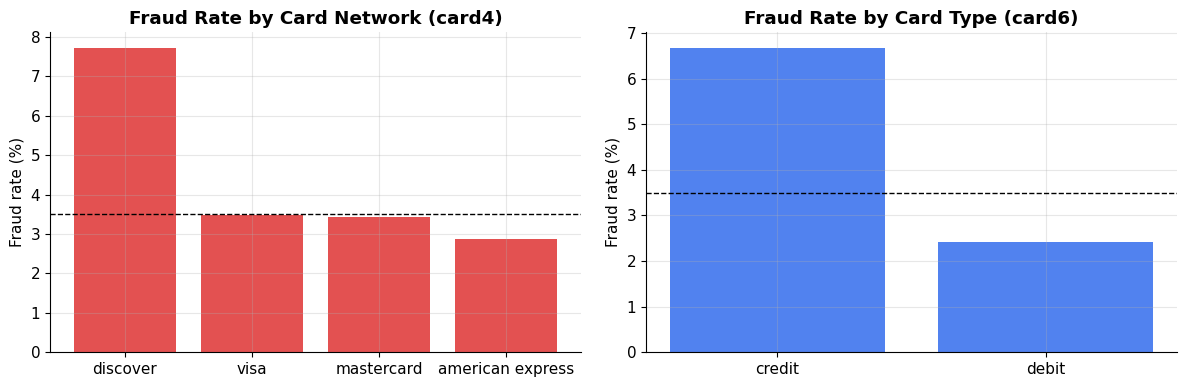

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# card4: card network (Visa, Mastercard, etc.)
card4_rate = (
    txn.groupby('card4')['isFraud']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'n'})
    .query('n > 1000')
    .sort_values('fraud_rate', ascending=False)
)
axes[0].bar(card4_rate.index, card4_rate['fraud_rate'] * 100,
            color=FRAUD_COLOR, alpha=0.8)
axes[0].axhline(fraud_rate * 100, linestyle='--', color='black', linewidth=1)
axes[0].set_ylabel('Fraud rate (%)')
axes[0].set_title('Fraud Rate by Card Network (card4)', fontweight='bold')

# card6: debit vs credit
card6_rate = (
    txn.groupby('card6')['isFraud']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'n'})
    .query('n > 1000')
    .sort_values('fraud_rate', ascending=False)
)
axes[1].bar(card6_rate.index, card6_rate['fraud_rate'] * 100,
            color=LEGIT_COLOR, alpha=0.8)
axes[1].axhline(fraud_rate * 100, linestyle='--', color='black', linewidth=1)
axes[1].set_ylabel('Fraud rate (%)')
axes[1].set_title('Fraud Rate by Card Type (card6)', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Email domains

Does the purchaser's email domain correlate with fraud?
Free email providers (gmail, yahoo) are harder to trace — a known fraud signal.

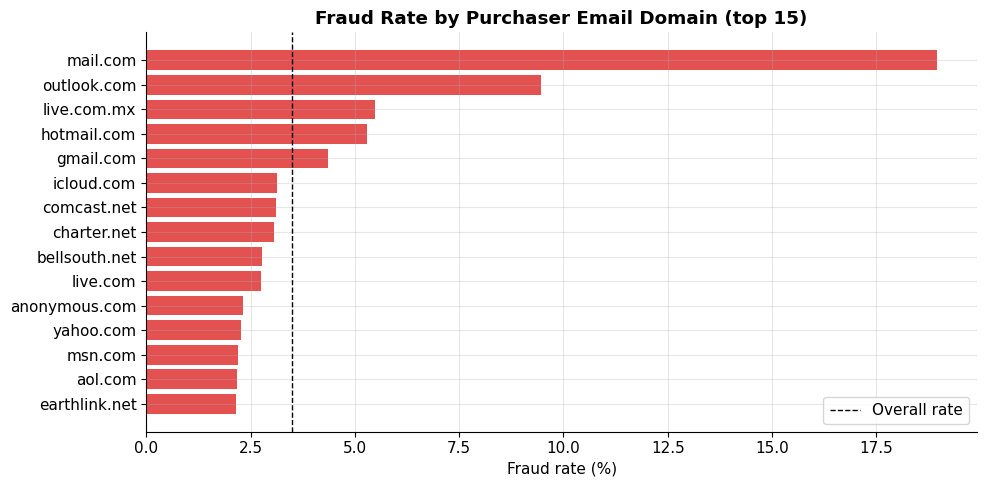

In [26]:
email_rate = (
    txn.groupby('P_emaildomain')['isFraud']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'fraud_rate', 'count': 'n'})
    .query('n > 500')
    .sort_values('fraud_rate', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(email_rate.index[::-1], email_rate['fraud_rate'][::-1] * 100,
        color=FRAUD_COLOR, alpha=0.8)
ax.axvline(fraud_rate * 100, linestyle='--', color='black',
           linewidth=1, label='Overall rate')
ax.set_xlabel('Fraud rate (%)')
ax.set_title('Fraud Rate by Purchaser Email Domain (top 15)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Identity table coverage

Not all transactions have an identity record. How many do?
And does having an identity record correlate with fraud?

In [27]:
df = txn.merge(idn[['TransactionID']], on='TransactionID', how='left', indicator=True)
df['has_identity'] = (df['_merge'] == 'both').astype(int)

coverage = df['has_identity'].mean()
print(f'Transactions with identity record : {coverage:.1%}')
print(f'Transactions without              : {1 - coverage:.1%}')
print()

fraud_with    = df[df['has_identity'] == 1]['isFraud'].mean()
fraud_without = df[df['has_identity'] == 0]['isFraud'].mean()
print(f'Fraud rate WITH identity record    : {fraud_with:.2%}')
print(f'Fraud rate WITHOUT identity record : {fraud_without:.2%}')

C:\Users\user\AppData\Local\Temp\ipykernel_20384\332779261.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = txn.merge(idn[['TransactionID']], on='TransactionID', how='left', indicator=True)
C:\Users\user\AppData\Local\Temp\ipykernel_20384\332779261.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = txn.merge(idn[['TransactionID']], on='TransactionID', how='left', indicator=True)
C:\Users\user\AppData\Local\Temp\ipykernel_20384\332779261.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

Transactions with identity record : 24.4%
Transactions without              : 75.6%

Fraud rate WITH identity record    : 7.85%
Fraud rate WITHOUT identity record : 2.09%


## 10. Temporal split preview

We will train on the first 75% of transactions by time and test on the last 25%.
Let's visualise where that boundary falls and check that fraud rates are stable across time.

C:\Users\user\AppData\Local\Temp\ipykernel_20384\1825322345.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  txn_sorted['time_bin'] = pd.cut(txn_sorted['TransactionDT'], bins=50, labels=False)


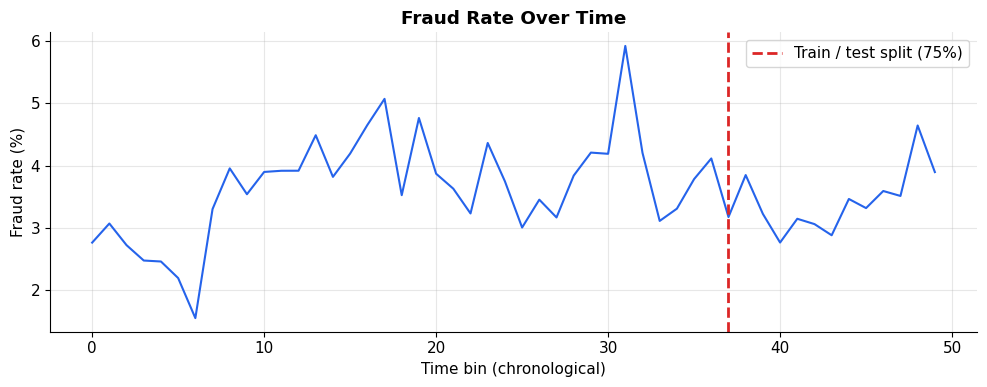

Train fraud rate : 3.51%
Test  fraud rate : 3.45%

If these rates are similar, the temporal split is clean.
Large divergence would signal concept drift between periods.


In [28]:
txn_sorted = txn.sort_values('TransactionDT')
split_idx  = int(len(txn_sorted) * 0.75)
split_dt   = txn_sorted['TransactionDT'].iloc[split_idx]

# Fraud rate over time (binned into 50 equal time windows)
txn_sorted['time_bin'] = pd.cut(txn_sorted['TransactionDT'], bins=50, labels=False)
time_fraud = txn_sorted.groupby('time_bin')['isFraud'].mean()

fig, ax = plt.subplots()
ax.plot(time_fraud.index, time_fraud.values * 100,
        color=LEGIT_COLOR, linewidth=1.5)
ax.axvline(37, color=FRAUD_COLOR, linestyle='--',
           linewidth=2, label='Train / test split (75%)')
ax.set_xlabel('Time bin (chronological)')
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud Rate Over Time', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

train_fraud = txn_sorted.iloc[:split_idx]['isFraud'].mean()
test_fraud  = txn_sorted.iloc[split_idx:]['isFraud'].mean()
print(f'Train fraud rate : {train_fraud:.2%}')
print(f'Test  fraud rate : {test_fraud:.2%}')
print()
print('If these rates are similar, the temporal split is clean.')
print('Large divergence would signal concept drift between periods.')

## 11. Key takeaways

Run this cell last — fill it in based on what you actually saw above.

In [29]:
print('=== EDA Summary ===')
print(f'Fraud rate               : {fraud_rate:.2%}')
print(f'V-features to keep       : {keep} of {len(v_cols)}')
print(f'Identity coverage        : {coverage:.1%}')
print(f'Train/test split at DT   : {split_dt:,}')
print()
print('Decisions this informs:')
print('  - Use PR-AUC as primary metric, not ROC-AUC or accuracy')
print('  - Use scale_pos_weight in LightGBM to handle imbalance')
print('  - Drop V-features with >50% missing')
print('  - Engineer is_night and is_weekend features')
print('  - Use target encoding for email domain and card columns')
print('  - Left join identity (keep all transactions)')
print('  - Temporal split, never random')

=== EDA Summary ===
Fraud rate               : 3.50%
V-features to keep       : 180 of 339
Identity coverage        : 24.4%
Train/test split at DT   : 11,246,665

Decisions this informs:
  - Use PR-AUC as primary metric, not ROC-AUC or accuracy
  - Use scale_pos_weight in LightGBM to handle imbalance
  - Drop V-features with >50% missing
  - Engineer is_night and is_weekend features
  - Use target encoding for email domain and card columns
  - Left join identity (keep all transactions)
  - Temporal split, never random
